# Python - PY4
## Modulo 2: Machine Learning Avanzado y Feature Engineering
### Modelo Interpretable: Regresion Logistica

**Objetivos de este notebook:**
- Escalar las variables numericas.
- Entrenar un modelo de Regresion Logistica.
- Evaluar el modelo con Accuracy, Precision, Recall y Matriz de Confusion.
- Interpretar los coeficientes del modelo para responder "por que" un cliente compra.



## 1. Recuperando los datos del Notebook 1

Cargamos las librerias y los datos que preparamos en el notebook anterior (`X_train`, `X_test`, `y_train`, `y_test`).


In [ ]:
# Manejo de datos
import pandas as pd
import numpy as np
import pickle # library para manejar Python formatted archivos

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import train_test_split

# Configuración

sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (8, 5)


Ejecuta esta celda para obtener los mismos datos que al final del notebook anterior.

In [ ]:
# Carga de datos
BASE_URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Module_02_machine_learning_and_feature_engineering/"
df = pd.read_csv(BASE_URL + "online_shoppers_intention.csv")

# Feature Engineering basico (igual que en el Notebook 1)
columnas_categoricas = df.select_dtypes(include="object").columns.tolist()
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)
df_encoded["Weekend"] = df_encoded["Weekend"].astype(int)
df_encoded["Revenue"] = df_encoded["Revenue"].astype(int)

# Separando Features (X) y Target (y)
X = df_encoded.drop(columns=["Revenue"])
y = df_encoded["Revenue"]

# Train/Test Split (mismo random_state que en el Notebook 1, para obtener el mismo split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamanio de entrenamiento:", X_train.shape)
print("Tamanio de prueba:", X_test.shape)

In [ ]:
#with open("datos_procesados.pkl", "rb") as f:
#    X, X_train, X_test, y_train, y_test = pickle.load(f)

#print("Tamanio de entrenamiento:", X_train.shape)
#print("Tamanio de prueba:", X_test.shape)


Tamanio de entrenamiento: (9864, 26)
Tamanio de prueba: (2466, 26)


## 2. Por que escalar los datos

La Regresion Logistica es sensible a la escala de las variables. Si una columna va de 0 a 1 y otra de 0 a 20,000 (como `PageValues`), el modelo le puede dar mas peso a la variable con numeros mas grandes sin que eso signifique que es mas importante.

Usamos `StandardScaler` para que todas las variables numericas queden con media 0 y desviacion estandar 1.

Importante: el scaler se **entrena (fit)** solo con los datos de entrenamiento, y luego se **aplica (transform)** tanto a train como a test. Esto evita fuga de informacion (data leakage) del set de prueba.


In [ ]:
scaler = StandardScaler()  # crea el scaler

# aprende la media y la desviación estándar de cada variable usando SOLO el train set,
# y luego transforma X_train para que cada variable tenga media ≈ 0 y desviación estándar ≈ 1
X_train_scaled = scaler.fit_transform(X_train)


# transforma el test set utilizando exactamente la misma sscale aprendida en X_train
# NO se debe usar "fit_transform" aquí, ya que el scaler calcularía nuevas medias y desviaciones
# a partir de X_test. Esto introduciría información del test set en el proceso de entrenamiento
# (data leakage), generando una evaluación del modelo demasiado optimista y poco realista.
X_test_scaled = scaler.transform(X_test)

In [ ]:
# checkear los datos scaled
pd.DataFrame(X_train_scaled).describe().round(2)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
count,9864.00,9864.00,9864.00,9864.00,9864.00,9864.00,9864.00,9864.00,9864.00,9864.00,...,9864.00,9864.00,9864.00,9864.00,9864.00,9864.00,9864.00,9864.00,9864.00,9864.00
mean,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,...,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.70,-0.45,-0.40,-0.24,-0.72,-0.62,-0.46,-0.89,-0.32,-0.31,...,-0.12,-0.19,-0.15,-0.43,-0.61,-0.56,-0.22,-0.20,-0.09,-2.44
25%,-0.70,-0.45,-0.40,-0.24,-0.56,-0.53,-0.46,-0.59,-0.32,-0.31,...,-0.12,-0.19,-0.15,-0.43,-0.61,-0.56,-0.22,-0.20,-0.09,0.41
50%,-0.40,-0.41,-0.40,-0.24,-0.31,-0.31,-0.40,-0.37,-0.32,-0.31,...,-0.12,-0.19,-0.15,-0.43,-0.61,-0.56,-0.22,-0.20,-0.09,0.41
75%,0.51,0.07,-0.40,-0.24,0.15,0.15,-0.11,0.14,-0.32,-0.31,...,-0.12,-0.19,-0.15,-0.43,1.63,-0.56,-0.22,-0.20,-0.09,0.41
max,7.44,18.47,18.43,17.78,15.44,32.89,3.64,3.20,19.17,4.66,...,8.16,5.26,6.50,2.33,1.63,1.78,4.61,5.08,11.50,0.41


## 3. Entrenando la Regresion Logistica

La Regresion Logistica es un modelo interpretable: cada variable tiene un coeficiente que nos dice como influye en la probabilidad de compra. Es el candidato ideal para explicarle a Marketing "el porque" detras de las predicciones.

*(Alternativa: si prefieres, puedes entrenar un `DecisionTreeClassifier` en su lugar. La logica de evaluacion e interpretacion es la misma.)*


## ¿Cómo funciona la Regresión Logística?

La regresión logística es un algoritmo de clasificación que estima la probabilidad de que una observación pertenezca a una clase (por ejemplo: 0 o 1).

En lugar de predecir directamente una clase, el modelo calcula un valor lineal:

$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n
$

Este valor puede ser cualquier número real, por lo que se transforma usando la **función sigmoide**:

$
\sigma(z) = \frac{1}{1 + e^{-z}}
$

### Intuición:
- Si \(z\) es muy negativo → la probabilidad se acerca a 0
- Si \(z\) es muy positivo → la probabilidad se acerca a 1
- Si \(z = 0\) → la probabilidad es 0.5

Luego, el modelo clasifica usando un umbral (por defecto 0.5):
- Probabilidad ≥ 0.5 → clase 1
- Probabilidad < 0.5 → clase 0

La curva sigmoide es la pieza clave de la regresión logística, ya que convierte cualquier valor real en una probabilidad interpretable entre 0 y 1.

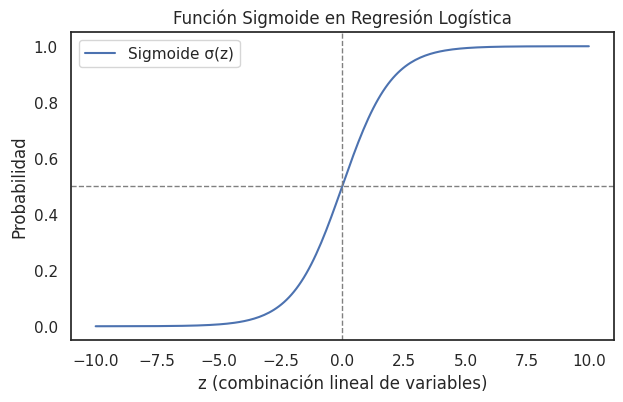

In [ ]:
# función sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# datos
z = np.linspace(-10, 10, 200)
y = sigmoid(z)

# gráfico
plt.figure(figsize=(7, 4))
sns.lineplot(x=z, y=y, label="Sigmoide σ(z)")

# líneas de referencia
plt.axhline(0.5, linestyle="--", color="gray", linewidth=1)
plt.axvline(0, linestyle="--", color="gray", linewidth=1)
plt.title("Función Sigmoide en Regresión Logística")
plt.xlabel("z (combinación lineal de variables)")
plt.ylabel("Probabilidad")
plt.legend()
plt.show()

### Entrenamos un modelo de Regresion Logistica

In [ ]:
modelo_logistico = LogisticRegression(
    max_iter=1000,  # 1000 iteraciones para asegurar la convergencia del algoritmo
    random_state=42  # fija la semilla aleatoria para obtener resultados reproducibles
)

modelo_logistico.fit(X_train_scaled, y_train)
# entrena (ajusta) el modelo usando las variables predictoras scaled (X_train_scaled) y la target variable (y_train)
# durante este proceso, el modelo aprende los coeficientes que mejor separan las clases

LogisticRegression(max_iter=1000, random_state=42)

## 4. Evaluando el modelo interpretable

Generamos las predicciones sobre el set de prueba y las comparamos contra los valores reales.


In [ ]:
# genera las predicciones del modelo para los datos de test
# el resultado es un vector con las clases predichas (por ejemplo, 0 o 1)
y_pred_log = modelo_logistico.predict(X_test_scaled)

print("Predicciones:", y_pred_log[0:10])
print("Valores reales:", y_test.values[0:10])

Predicciones: [0 0 1 0 0 0 0 0 0 0]
Valores reales: [0 0 1 0 0 0 1 0 0 0]


In [ ]:
# compara las clases reales (y_test) con las clases predichas (y_pred_log)
# y calcula el porcentaje de aciertos del modelo
accuracy_log = accuracy_score(y_test, y_pred_log)

# imprime la métrica de accuracy
# por ejemplo, un accuracy de 0.88 significa que el modelo clasificó correctamente el 85% de las observaciones del conjunto de prueba
print(f"Accuracy del modelo logístico: {accuracy_log:.4f}")


Accuracy del modelo logístico: 0.8812


### Matriz de Confusion

El Accuracy solo no nos dice toda la historia (recuerda el desbalance de clases). La Matriz de Confusion nos muestra exactamente donde se equivoca el modelo:

- **Falsos Positivos (FP):** el modelo dijo "va a comprar" pero no compro -> descuentos innecesarios, se pierde dinero.
- **Falsos Negativos (FN):** el modelo dijo "no va a comprar" pero si compro -> se pierde una venta por no ofrecer el incentivo a tiempo.


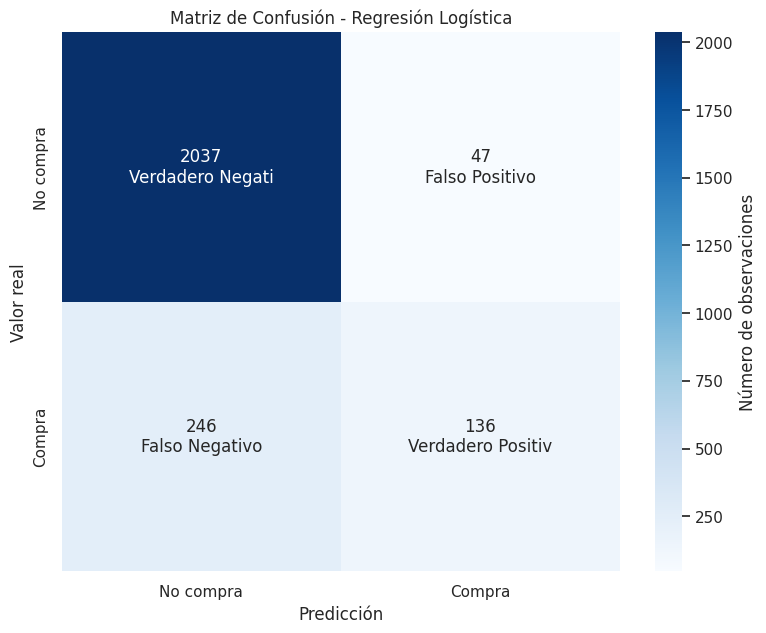

In [ ]:
# construye la matriz de confusión comparando las clases reales (y_test) con las clases predichas por el modelo (y_pred_log)

# matriz de confusión
matriz_log = confusion_matrix(y_test, y_pred_log)

# etiquetas interpretativas
labels = np.array([
    ["Verdadero Negativo", "Falso Positivo"],
    ["Falso Negativo", "Verdadero Positivo"]
])

# combinar número + explicación
annot = np.empty_like(matriz_log).astype(str)

for i in range(matriz_log.shape[0]):
    for j in range(matriz_log.shape[1]):
        annot[i, j] = f"{matriz_log[i, j]}\n{labels[i, j]}"

plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_log,
    annot=annot,   # muestra número + texto
    fmt="",
    cmap="Blues",
    xticklabels=["No compra", "Compra"],
    yticklabels=["No compra", "Compra"],
    cbar_kws={"label": "Número de observaciones"}
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Regresión Logística")

plt.show()


### Precision y Recall (obligatorio analizarlos)

- **Precision:** de todos los que el modelo predijo como "compra", cuantos realmente compraron. Una precision baja significa muchos Falsos Positivos (descuentos regalados).
- **Recall:** de todos los que realmente compraron, cuantos detecto el modelo. Un recall bajo significa muchos Falsos Negativos (ventas perdidas).


### F1-score

$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$

El **F1-score** es una métrica que combina la *precisión* y el *recall* en un solo valor.

Un valor más cercano a 1 indica un mejor performance del modelo.

In [ ]:
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print(f"Precision: {precision_log:.4f}")
print(f"Recall:    {recall_log:.4f}")
print(f"F1-score:  {f1_log:.4f}")

print("\nReporte completo de clasificacion:")
print(classification_report(y_test, y_pred_log, target_names=["No compra", "Compra"]))


Precision: 0.7432
Recall:    0.3560
F1-score:  0.4814

Reporte completo de clasificacion:
              precision    recall  f1-score   support

   No compra       0.89      0.98      0.93      2084
      Compra       0.74      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



## 5. Interpretando el modelo: que variables influyen mas

Una de las grandes ventajas de la Regresion Logistica es que podemos ver el coeficiente de cada variable. Un coeficiente positivo grande significa que esa variable aumenta la probabilidad de compra; uno negativo grande, que la reduce.


In [ ]:
# crea un DataFrame con los coeficientes aprendidos por el modelo
# cada coeficiente indica el impacto de la variable en la predicción
# se ordenan de mayor a menor para identificar las variables más influyentes
coeficientes = pd.DataFrame({
    "variable": X.columns, # extrae los features
    "coeficiente": modelo_logistico.coef_[0] # extrae el vector de coeficientes (1D)
}).sort_values(by="coeficiente", ascending=False)

coeficientes.head(15)

# valores positivos aumentan la probabilidad de la clase 1, valores negativos la disminuyen

,variable,coeficiente
8,PageValues,1.536608
21,Month_Nov,0.178667
4,ProductRelated,0.093474
5,ProductRelated_Duration,0.079986
11,Browser,0.064547
14,Weekend,0.058456
2,Informational,0.053617
13,TrafficType,0.028951
1,Administrative_Duration,0.011985
23,Month_Sep,0.006564


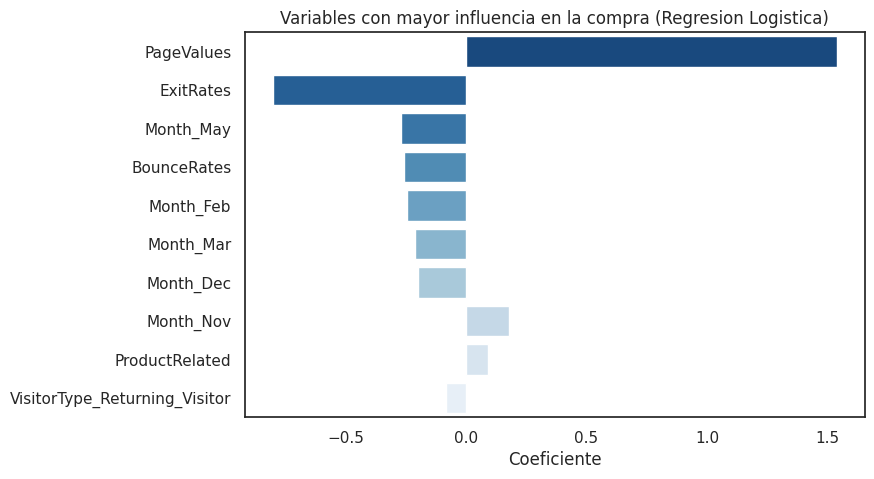

In [ ]:
# Visualizamos las 10 variables con mayor impacto (positivo o negativo)
top_coeficientes = coeficientes.reindex(
    coeficientes.coeficiente.abs().sort_values(ascending=False).index # enfocamos en el absolute value (positive y negative influence)
).head(10)

sns.barplot(data=top_coeficientes, x="coeficiente", y="variable", hue="variable", palette="Blues_r")
plt.xlabel("Coeficiente")
plt.ylabel("")
plt.title("Variables con mayor influencia en la compra (Regresion Logistica)")
plt.show()


## 6. Otro modelo interpretable: Arbol de Decision

La Regresion Logistica no es el unico modelo "explicable". Otro clasico para este tipo de problemas es el **Arbol de Decision**: un modelo que clasifica haciendo una serie de preguntas tipo si/no sobre las variables (por ejemplo: "PageValues > 5?"), hasta llegar a una prediccion final.

A diferencia de la Regresion Logistica, el arbol **no necesita variables escaladas**, y se puede dibujar directamente como un diagrama de flujo, lo que lo hace muy facil de explicar a alguien no tecnico.

Para que siga siendo interpretable (y no se convierta en un arbol gigante e ilegible), vamos a limitar su profundidad con el parametro `max_depth`.


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

modelo_arbol = DecisionTreeClassifier(
    max_depth=4,      # limitamos la profundidad para que el arbol siga siendo facil de leer
    random_state=42   # fija la semilla aleatoria para obtener resultados reproducibles
)

modelo_arbol.fit(X_train, y_train)  # a diferencia de la Regresion Logistica, no usamos las variables escaladas


DecisionTreeClassifier(max_depth=4, random_state=42)

### Evaluando el Arbol de Decision

Repetimos el mismo proceso de evaluacion que usamos para la Regresion Logistica, para poder comparar ambos modelos de forma justa.


In [ ]:
# genera las predicciones del arbol para los datos de test
y_pred_arbol = modelo_arbol.predict(X_test)

# calculamos las mismas metricas que usamos para la Regresion Logistica
accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
precision_arbol = precision_score(y_test, y_pred_arbol)
recall_arbol = recall_score(y_test, y_pred_arbol)
f1_arbol = f1_score(y_test, y_pred_arbol)

print(f"Accuracy:  {accuracy_arbol:.4f}")
print(f"Precision: {precision_arbol:.4f}")
print(f"Recall:    {recall_arbol:.4f}")
print(f"F1-score:  {f1_arbol:.4f}")


Accuracy:  0.8962
Precision: 0.7739
Recall:    0.4660
F1-score:  0.5817


### Visualizando el arbol

Una de las grandes ventajas del Arbol de Decision es que se puede dibujar. Cada caja representa una pregunta sobre una variable; siguiendo el camino de Verdadero/Falso llegamos a una prediccion.


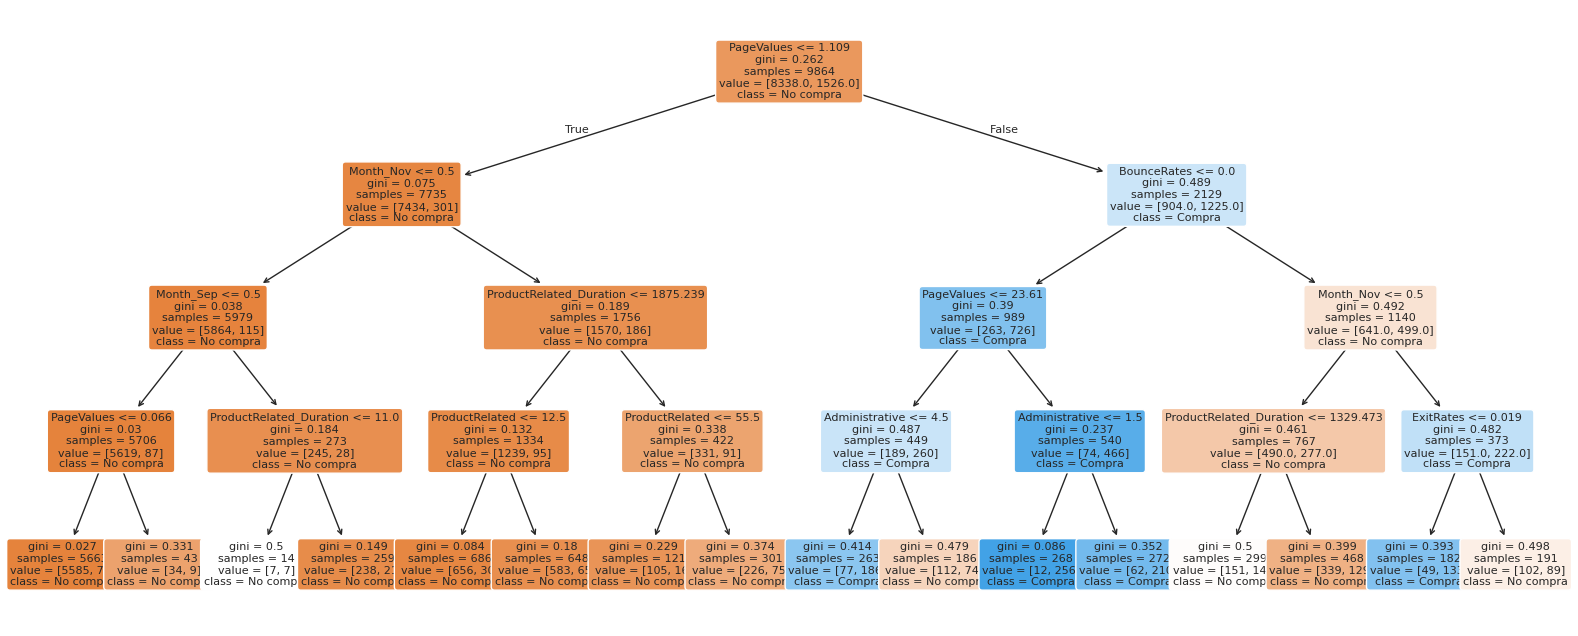

In [ ]:
plt.figure(figsize=(20, 8))
plot_tree(
    modelo_arbol,
    feature_names=X.columns,
    class_names=["No compra", "Compra"],
    filled=True,     # colorea cada caja segun la clase predominante
    rounded=True,
    fontsize=8
)
plt.show()


En un árbol de decisión, el índice de Gini (o impureza de Gini) es una medida de qué tan “mezcladas” están las clases dentro de un nodo.  

* Si un nodo contiene solo una clase → es puro → Gini = 0
* Si las clases están completamente mezcladas → la impureza es alta → Gini cercano a 0.5 (en clasificación binaria)



### Importancia de variables en el arbol

El arbol no tiene coeficientes como la Regresion Logistica, pero si nos dice que variables uso para hacer las divisiones (splits), y que tan importante fue cada una para reducir el error del modelo.


In [ ]:
# crea un DataFrame con la importancia de cada variable segun el arbol
importancia_arbol = pd.DataFrame({
    "variable": X.columns,
    "importancia": modelo_arbol.feature_importances_
}).sort_values(by="importancia", ascending=False)

importancia_arbol.head(10)


,variable,importancia
8,PageValues,0.814930
6,BounceRates,0.075522
21,Month_Nov,0.038881
5,ProductRelated_Duration,0.028895
0,Administrative,0.024286
7,ExitRates,0.010611
4,ProductRelated,0.003648
23,Month_Sep,0.003225
1,Administrative_Duration,0.000000
3,Informational_Duration,0.000000


### Regresion Logistica vs Arbol de Decision: primera comparacion

Compara los numeros de Accuracy, Precision, Recall y F1 del Arbol de Decision contra los que obtuviste para la Regresion Logistica en la seccion 4. Piensa:

- Cual modelo tiene mejor Recall? Cual mejor Precision?
- Al ver el diagrama del arbol, te parece mas facil de explicarle a alguien de Marketing que los coeficientes de la Regresion Logistica?

Guarda esta intuicion: en el Notebook 3 vamos a sumar un tercer modelo, Random Forest, que es basicamente construir cientos de arboles como este y combinar sus resultados.


### Guardando los resultados del arbol

Guardamos las metricas del Arbol de Decision en un archivo separado, para poder usarlas mas adelante si queremos compararlas junto con la Regresion Logistica y el Random Forest.


In [ ]:
with open("resultados_arbol.pkl", "wb") as f:
    pickle.dump(
        {
            "accuracy": accuracy_arbol,
            "precision": precision_arbol,
            "recall": recall_arbol,
            "f1": f1_arbol,
            "importancia": importancia_arbol,
        },
        f,
    )

print("Resultados guardados en 'resultados_arbol.pkl'")


Resultados guardados en 'resultados_arbol.pkl'


## 7. Guardando nuestro trabajo para el siguiente notebook

En el Notebook 3 vamos a comparar este modelo contra un Random Forest, asi que guardamos las metricas y las predicciones.


In [ ]:
with open("resultados_logistico.pkl", "wb") as f:
    pickle.dump(
        {
            "accuracy": accuracy_log,
            "precision": precision_log,
            "recall": recall_log,
            "f1": f1_log,
            "matriz_confusion": matriz_log,
            "coeficientes": coeficientes,
        },
        f,
    )

print("Resultados guardados en 'resultados_logistico.pkl'")


Resultados guardados en 'resultados_logistico.pkl'


## Cierre del Notebook 2

Preguntas para reflexionar antes del Notebook 3:

1. Segun los coeficientes, cual es la variable que mas empuja a un visitante a comprar?
2. Con los numeros de Precision y Recall que obtuviste, si tuvieras que elegir entre evitar Falsos Positivos o evitar Falsos Negativos, cual priorizarias para este negocio? Por que?

Continua en **Notebook 3: Modelo de caja negra (Random Forest), comparacion y reporte ejecutivo**.
